# SEAS5 2025 trigger
<!-- markdownlint-disable MD013 -->
Combining raster stats for Sahel and Centre-Nord

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [10]:
import calendar

import pandas as pd
import numpy as np
import ocha_stratus as stratus
import matplotlib.pyplot as plt

from src.constants import *
from src.utils import rp_calc

In [11]:
engine = stratus.get_engine("prod")
pcodes = ADM1_AOI_PCODES

In [4]:
query = f"""
SELECT *
FROM public.polygon
WHERE pcode IN {tuple(pcodes)}
"""
df_adm = pd.read_sql(query, engine)

In [5]:
query = f"""
SELECT *
FROM public.seas5
WHERE pcode in {tuple(pcodes)}
"""
df_seas5 = pd.read_sql(
    query, engine, parse_dates=["valid_date", "issued_date"]
)

In [6]:
df_seas5 = df_seas5.merge(df_adm)

In [12]:
pcodes

['BF56', 'BF49']

In [8]:
df_seas5.columns

Index(['iso3', 'pcode', 'valid_date', 'issued_date', 'leadtime', 'adm_level',
       'mean', 'median', 'min', 'max', 'count', 'sum', 'std', 'name',
       'name_language', 'area', 'standard', 'imerg_n_intersect_raw_pixels',
       'imerg_frac_raw_pixels', 'imerg_n_upsampled_pixels',
       'era5_n_intersect_raw_pixels', 'era5_frac_raw_pixels',
       'era5_n_upsampled_pixels', 'floodscan_n_intersect_raw_pixels',
       'floodscan_frac_raw_pixels', 'floodscan_n_upsampled_pixels',
       'seas5_n_intersect_raw_pixels', 'seas5_frac_raw_pixels',
       'seas5_n_upsampled_pixels'],
      dtype='object')

In [17]:
df_seas5 = df_seas5[df_seas5["pcode"].isin(pcodes)].copy()

In [18]:
df_seas5["name"].unique()

array(['Centre-Nord', 'Sahel'], dtype=object)

In [19]:
val_col = "mean"
weight_col = "seas5_frac_raw_pixels"
df_seas5["val_weighted"] = df_seas5[val_col] * df_seas5[weight_col]

In [20]:
df_seas5_grouped = (
    df_seas5.groupby(["valid_date", "issued_date"])[
        ["val_weighted", weight_col]
    ]
    .sum()
    .reset_index()
)

In [21]:
df_seas5_grouped[val_col] = (
    df_seas5_grouped["val_weighted"] / df_seas5_grouped[weight_col]
)

In [22]:
df_seas5_grouped = df_seas5_grouped.drop(columns=[weight_col, "val_weighted"])

<Axes: xlabel='issued_date'>

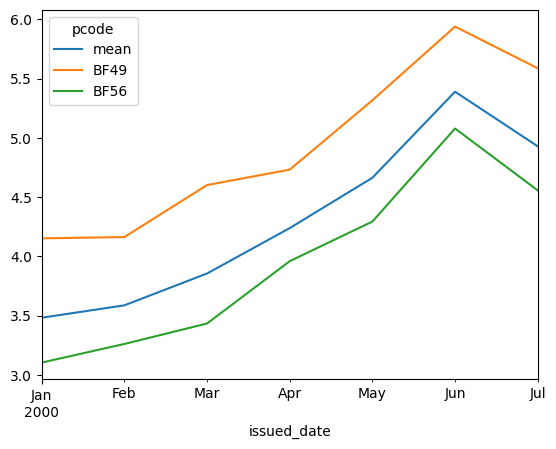

In [23]:
# just double check that weighted mean values look correct
valid_date = "2000-07-01"

fig, ax = plt.subplots()
df_seas5_grouped[df_seas5_grouped["valid_date"] == valid_date].plot(
    x="issued_date", y=val_col, ax=ax
)

df_plot = df_seas5.pivot(
    columns="pcode", index=["valid_date", "issued_date"], values="mean"
).reset_index()

df_plot[df_plot["valid_date"] == valid_date].drop(columns="valid_date").plot(
    x="issued_date", ax=ax
)

In [24]:
df_seas5

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,...,era5_n_intersect_raw_pixels,era5_frac_raw_pixels,era5_n_upsampled_pixels,floodscan_n_intersect_raw_pixels,floodscan_frac_raw_pixels,floodscan_n_upsampled_pixels,seas5_n_intersect_raw_pixels,seas5_frac_raw_pixels,seas5_n_upsampled_pixels,val_weighted
0,BFA,BF49,1992-01-01,1992-01-01,0,1,0.000377,0.000327,7.543713e-05,0.000930,...,41,26.28,657,250,234.98839,650,20,10.28125,658,0.003876
2,BFA,BF56,1992-01-01,1992-01-01,0,1,0.000558,0.000453,1.005828e-04,0.001634,...,70,47.08,1177,459,427.31732,1182,29,18.18750,1164,0.010140
3,BFA,BF49,1992-02-01,1992-02-01,0,1,0.000935,0.000754,2.514571e-05,0.002489,...,41,26.28,657,250,234.98839,650,20,10.28125,658,0.009617
5,BFA,BF56,1992-02-01,1992-02-01,0,1,0.000920,0.000855,-3.234563e-20,0.002364,...,70,47.08,1177,459,427.31732,1182,29,18.18750,1164,0.016738
6,BFA,BF49,1992-02-01,1992-01-01,1,1,0.012437,0.011779,4.360690e-03,0.023069,...,41,26.28,657,250,234.98839,650,20,10.28125,658,0.127864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11228,BFA,BF56,2025-10-01,2025-06-01,4,1,0.120008,0.103948,7.212135e-02,0.218435,...,70,47.08,1177,459,427.31732,1182,29,18.18750,1164,2.182643
11229,BFA,BF49,2025-11-01,2025-06-01,5,1,0.000523,0.000431,2.218739e-04,0.001528,...,41,26.28,657,250,234.98839,650,20,10.28125,658,0.005376
11231,BFA,BF56,2025-11-01,2025-06-01,5,1,0.000625,0.000530,1.848949e-04,0.003501,...,70,47.08,1177,459,427.31732,1182,29,18.18750,1164,0.011364
11232,BFA,BF49,2025-12-01,2025-06-01,6,1,0.001082,0.000789,3.081582e-04,0.008998,...,41,26.28,657,250,234.98839,650,20,10.28125,658,0.011126


In [114]:
names_str = ", ".join(df_seas5["name"].unique())

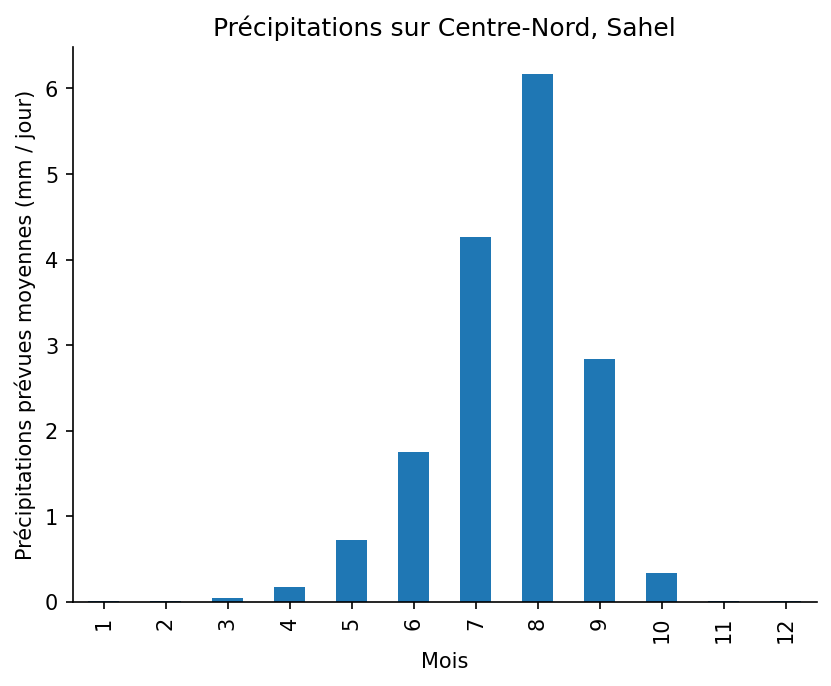

In [132]:
fig, ax = plt.subplots(dpi=150)

df_seas5.groupby(df_seas5["valid_date"].dt.month)["mean"].mean().plot.bar(
    ax=ax
)

ax.set_xlabel("Mois")
ax.set_ylabel("Précipitations prévues moyennes (mm / jour)")
ax.set_title(f"Précipitations sur {names_str}")

ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

In [29]:
season_months = [7, 8, 9]

In [31]:
df_seas5_grouped

,valid_date,issued_date,mean
0,1981-01-01,1981-01-01,0.000014
1,1981-02-01,1981-01-01,0.008086
2,1981-02-01,1981-02-01,0.010667
3,1981-03-01,1981-01-01,0.027721
4,1981-03-01,1981-02-01,0.046527
...,...,...,...
3740,2025-11-01,2025-06-01,0.000588
3741,2025-11-01,2025-07-01,0.028770
3742,2025-12-01,2025-06-01,0.000728
3743,2025-12-01,2025-07-01,0.000206


In [32]:
df_seas5_season = df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == df_seas5_grouped["issued_date"])
    & (df_seas5_grouped["valid_date"].dt.month.isin(season_months))
    & (df_seas5_grouped["valid_date"].dt.year < 2025)
].copy()
df_seas5_season["year"] = df_seas5_season["valid_date"].dt.year
df_seas5_season["month"] = df_seas5_season["valid_date"].dt.month
df_seas5_season = df_seas5_season.drop(columns=["valid_date", "issued_date"])

In [33]:
df_seas5_season = rp_calc.calculate_groups_rp(
    df_seas5_season, by=["month"], ascending=False
)

In [65]:
dicts = []
total_years = df_seas5_season["year"].nunique()
for rp_ind in df_seas5_season["mean_rp"].unique():
    dff = df_seas5_season[df_seas5_season["mean_rp"] >= rp_ind]
    dicts.append(
        {"rp_ind": rp_ind, "rp_com": (total_years + 1) / dff["year"].nunique()}
    )

df_rps = pd.DataFrame(dicts).sort_values("rp_ind", ascending=True)

In [111]:
df_rps

,rp_ind,rp_com
16,1.022727,1.022727
25,1.046512,1.022727
33,1.071429,1.022727
15,1.097561,1.022727
11,1.125000,1.022727
12,1.153846,1.022727
42,1.184211,1.022727
21,1.216216,1.022727
20,1.250000,1.022727
14,1.285714,1.022727


In [112]:
rp_ind = 3.75

In [113]:
rp_com = np.interp(rp_ind, df_rps["rp_ind"], df_rps["rp_com"])

In [122]:
def plot_activations(rp_ind):
    # df_rps = df_rps.sort_values("rp_ind", ascending=True)
    rp_com = np.interp(rp_ind, df_rps["rp_ind"], df_rps["rp_com"])
    min_year = 2000

    fig, axs = plt.subplots(nrows=3, figsize=(10, 10), sharex=True, dpi=200)

    trig_color = "crimson"

    dicts = []
    for i, (month, group) in enumerate(df_seas5_season.groupby("month")):
        group = group.sort_values("mean_rp").copy()
        thresh = np.interp(rp_ind, group["mean_rp"], group["mean"])

        ax = axs[i]

        df_plot = group[group["year"] >= min_year].sort_values("year")
        colors = [
            "grey" if v < thresh else trig_color for v in df_plot["mean"]
        ]
        df_plot.plot.bar(
            x="year", y="mean", ax=ax, legend=False, color=colors, alpha=0.6
        )
        ax.set_title(FRENCH_MONTHS[calendar.month_abbr[month]].capitalize())
        ax.axhline(thresh, color=trig_color, linestyle="--", linewidth=1)
        ax.annotate(
            f"   Seuil :\n   {thresh:.2f} mm",
            (len(df_plot) - 1, thresh),
            va="center",
            color=trig_color,
        )
        if i == 1:
            ax.set_ylabel(
                "Précipitations quotidiennes moyennes prévues (mm) [SEAS5]"
            )

        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)

        dicts.append({"month": month, "thresh": thresh})

    axs[-1].set_xlabel("Année")

    fig.suptitle(
        f"Précipitations sur {names_str}, moyenne sur toute la zone, prévues avec délai de 0 mois\n"
        f"Période de retour par mois = {rp_ind:.1f} ans; Période de retour globale = {rp_com:.1f} ans",
        y=0.95,
    )

    df_threshs = pd.DataFrame(dicts)

    display(df_threshs)

    return fig, axs

In [123]:
df_rps

,rp_ind,rp_com
16,1.022727,1.022727
25,1.046512,1.022727
33,1.071429,1.022727
15,1.097561,1.022727
11,1.125000,1.022727
12,1.153846,1.022727
42,1.184211,1.022727
21,1.216216,1.022727
20,1.250000,1.022727
14,1.285714,1.022727


,month,thresh
0,7,5.375626
1,8,7.882645
2,9,4.299739


(<Figure size 2000x2000 with 3 Axes>,
 array([<Axes: title={'center': 'Juil.'}, xlabel='year'>,
        <Axes: title={'center': 'Août'}, xlabel='year', ylabel='Précipitations quotidiennes moyennes prévues (mm) [SEAS5]'>,
        <Axes: title={'center': 'Sept.'}, xlabel='Année'>], dtype=object))

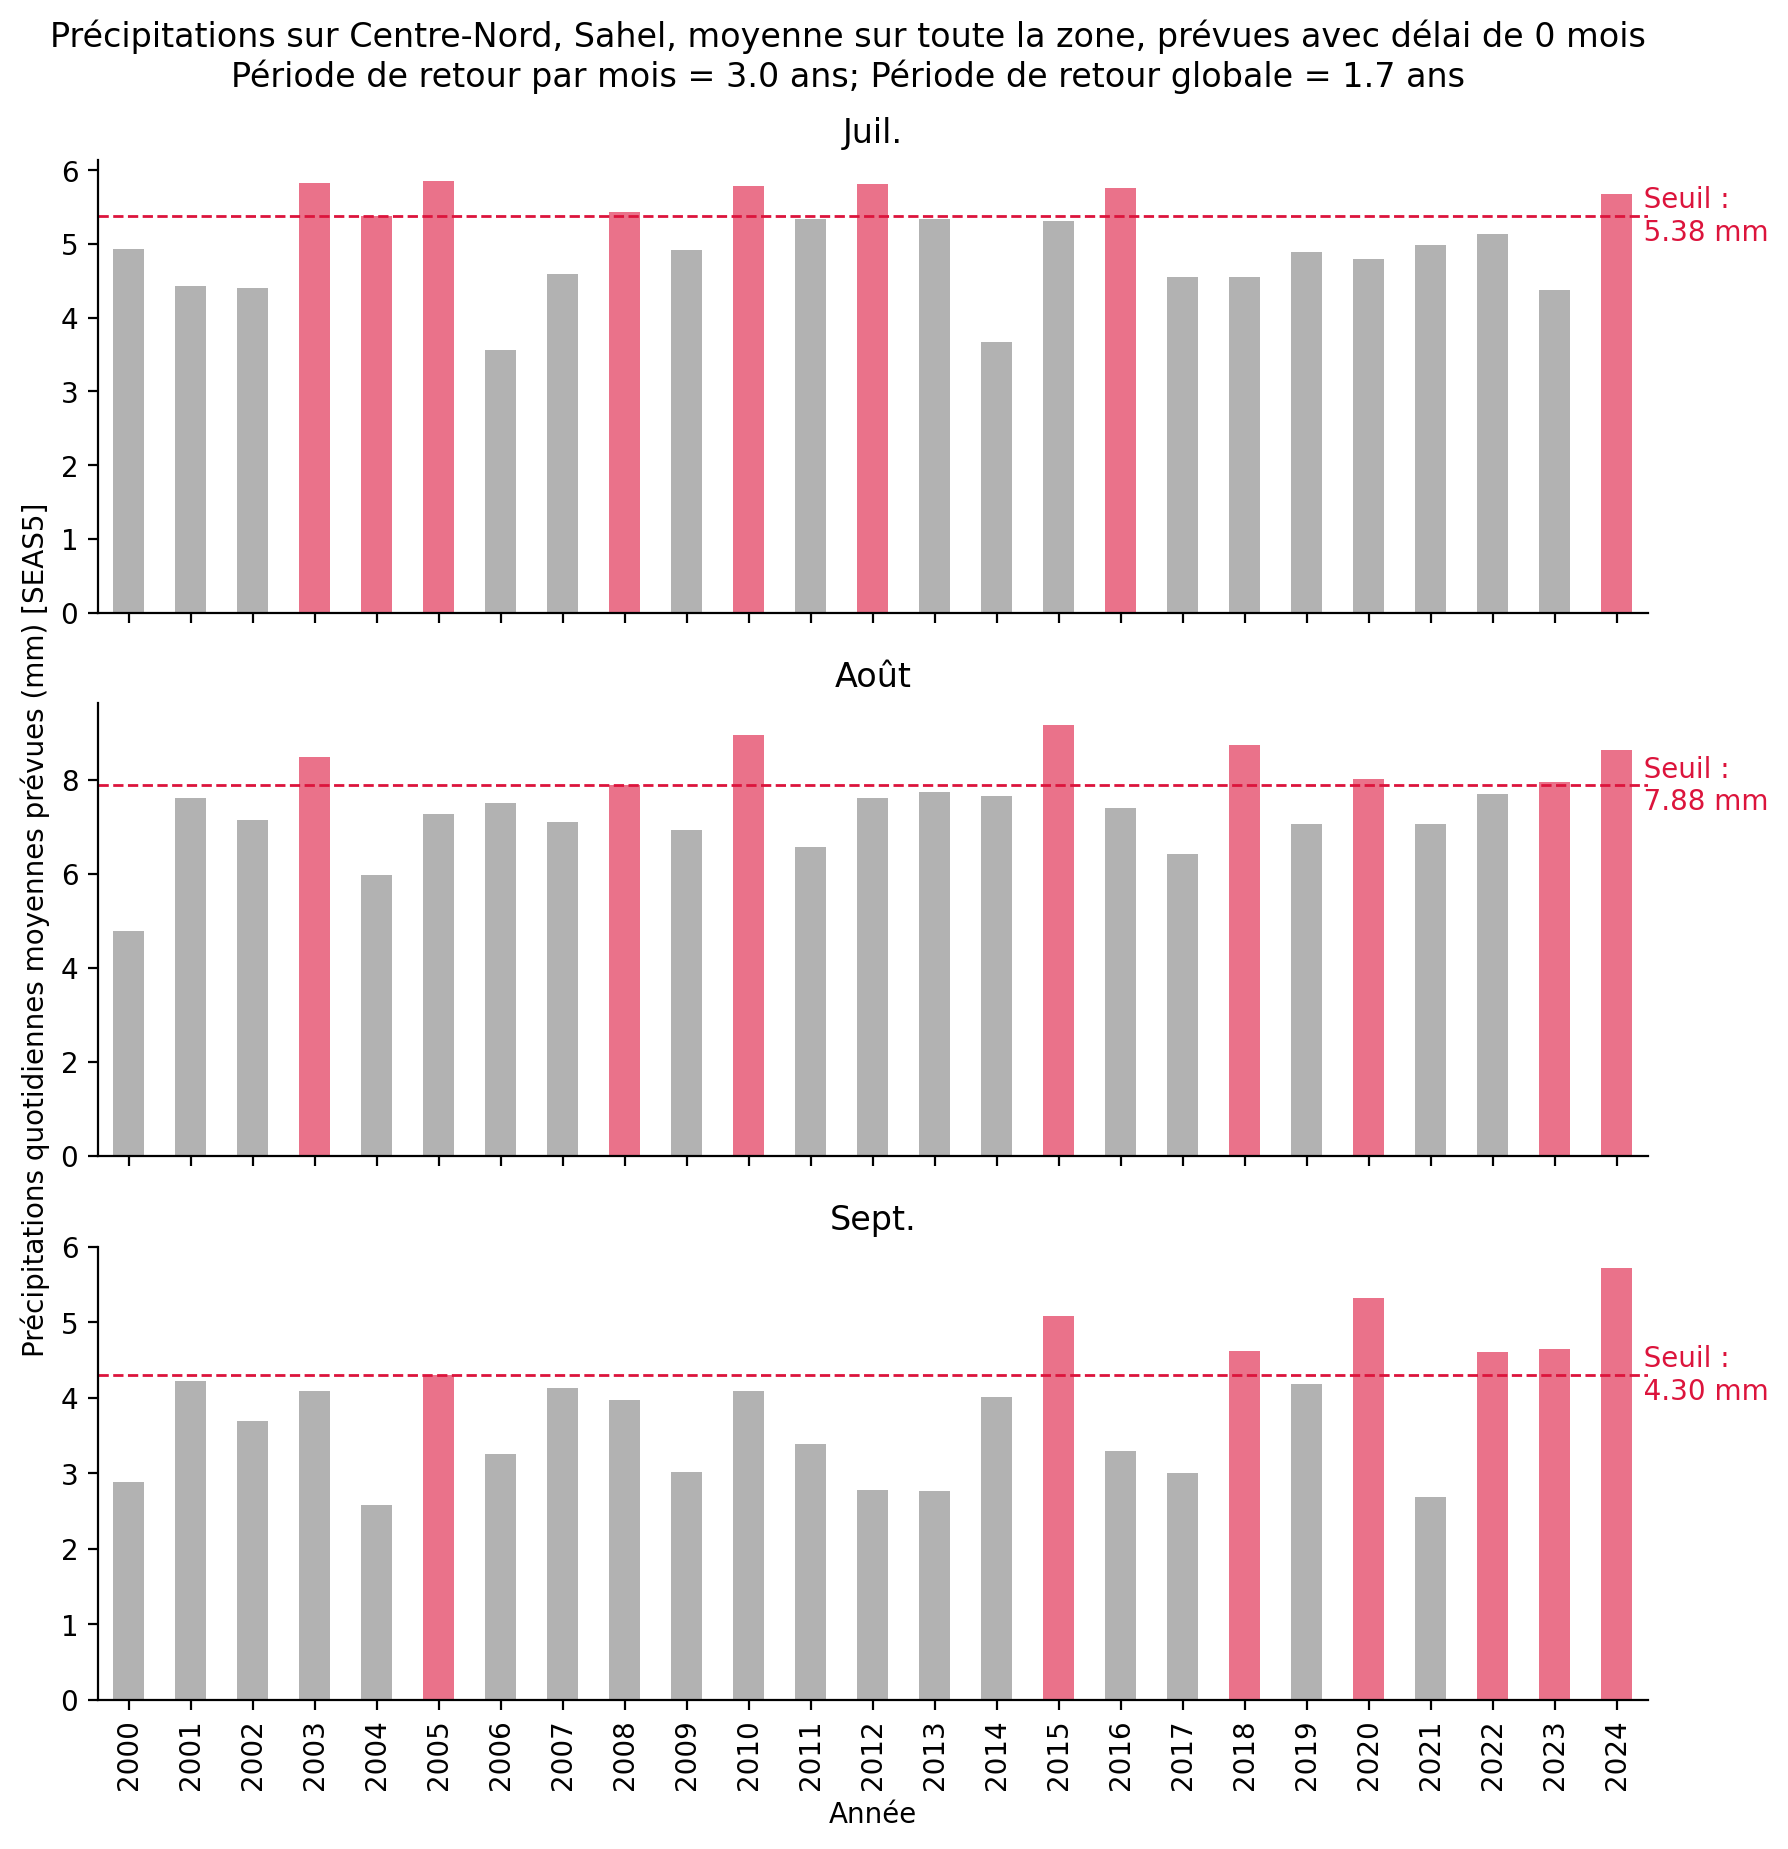

In [124]:
plot_activations(3)

,month,thresh
0,7,5.521046
1,8,7.972223
2,9,4.428126


(<Figure size 2000x2000 with 3 Axes>,
 array([<Axes: title={'center': 'Juil.'}, xlabel='year'>,
        <Axes: title={'center': 'Août'}, xlabel='year', ylabel='Précipitations quotidiennes moyennes prévues (mm) [SEAS5]'>,
        <Axes: title={'center': 'Sept.'}, xlabel='Année'>], dtype=object))

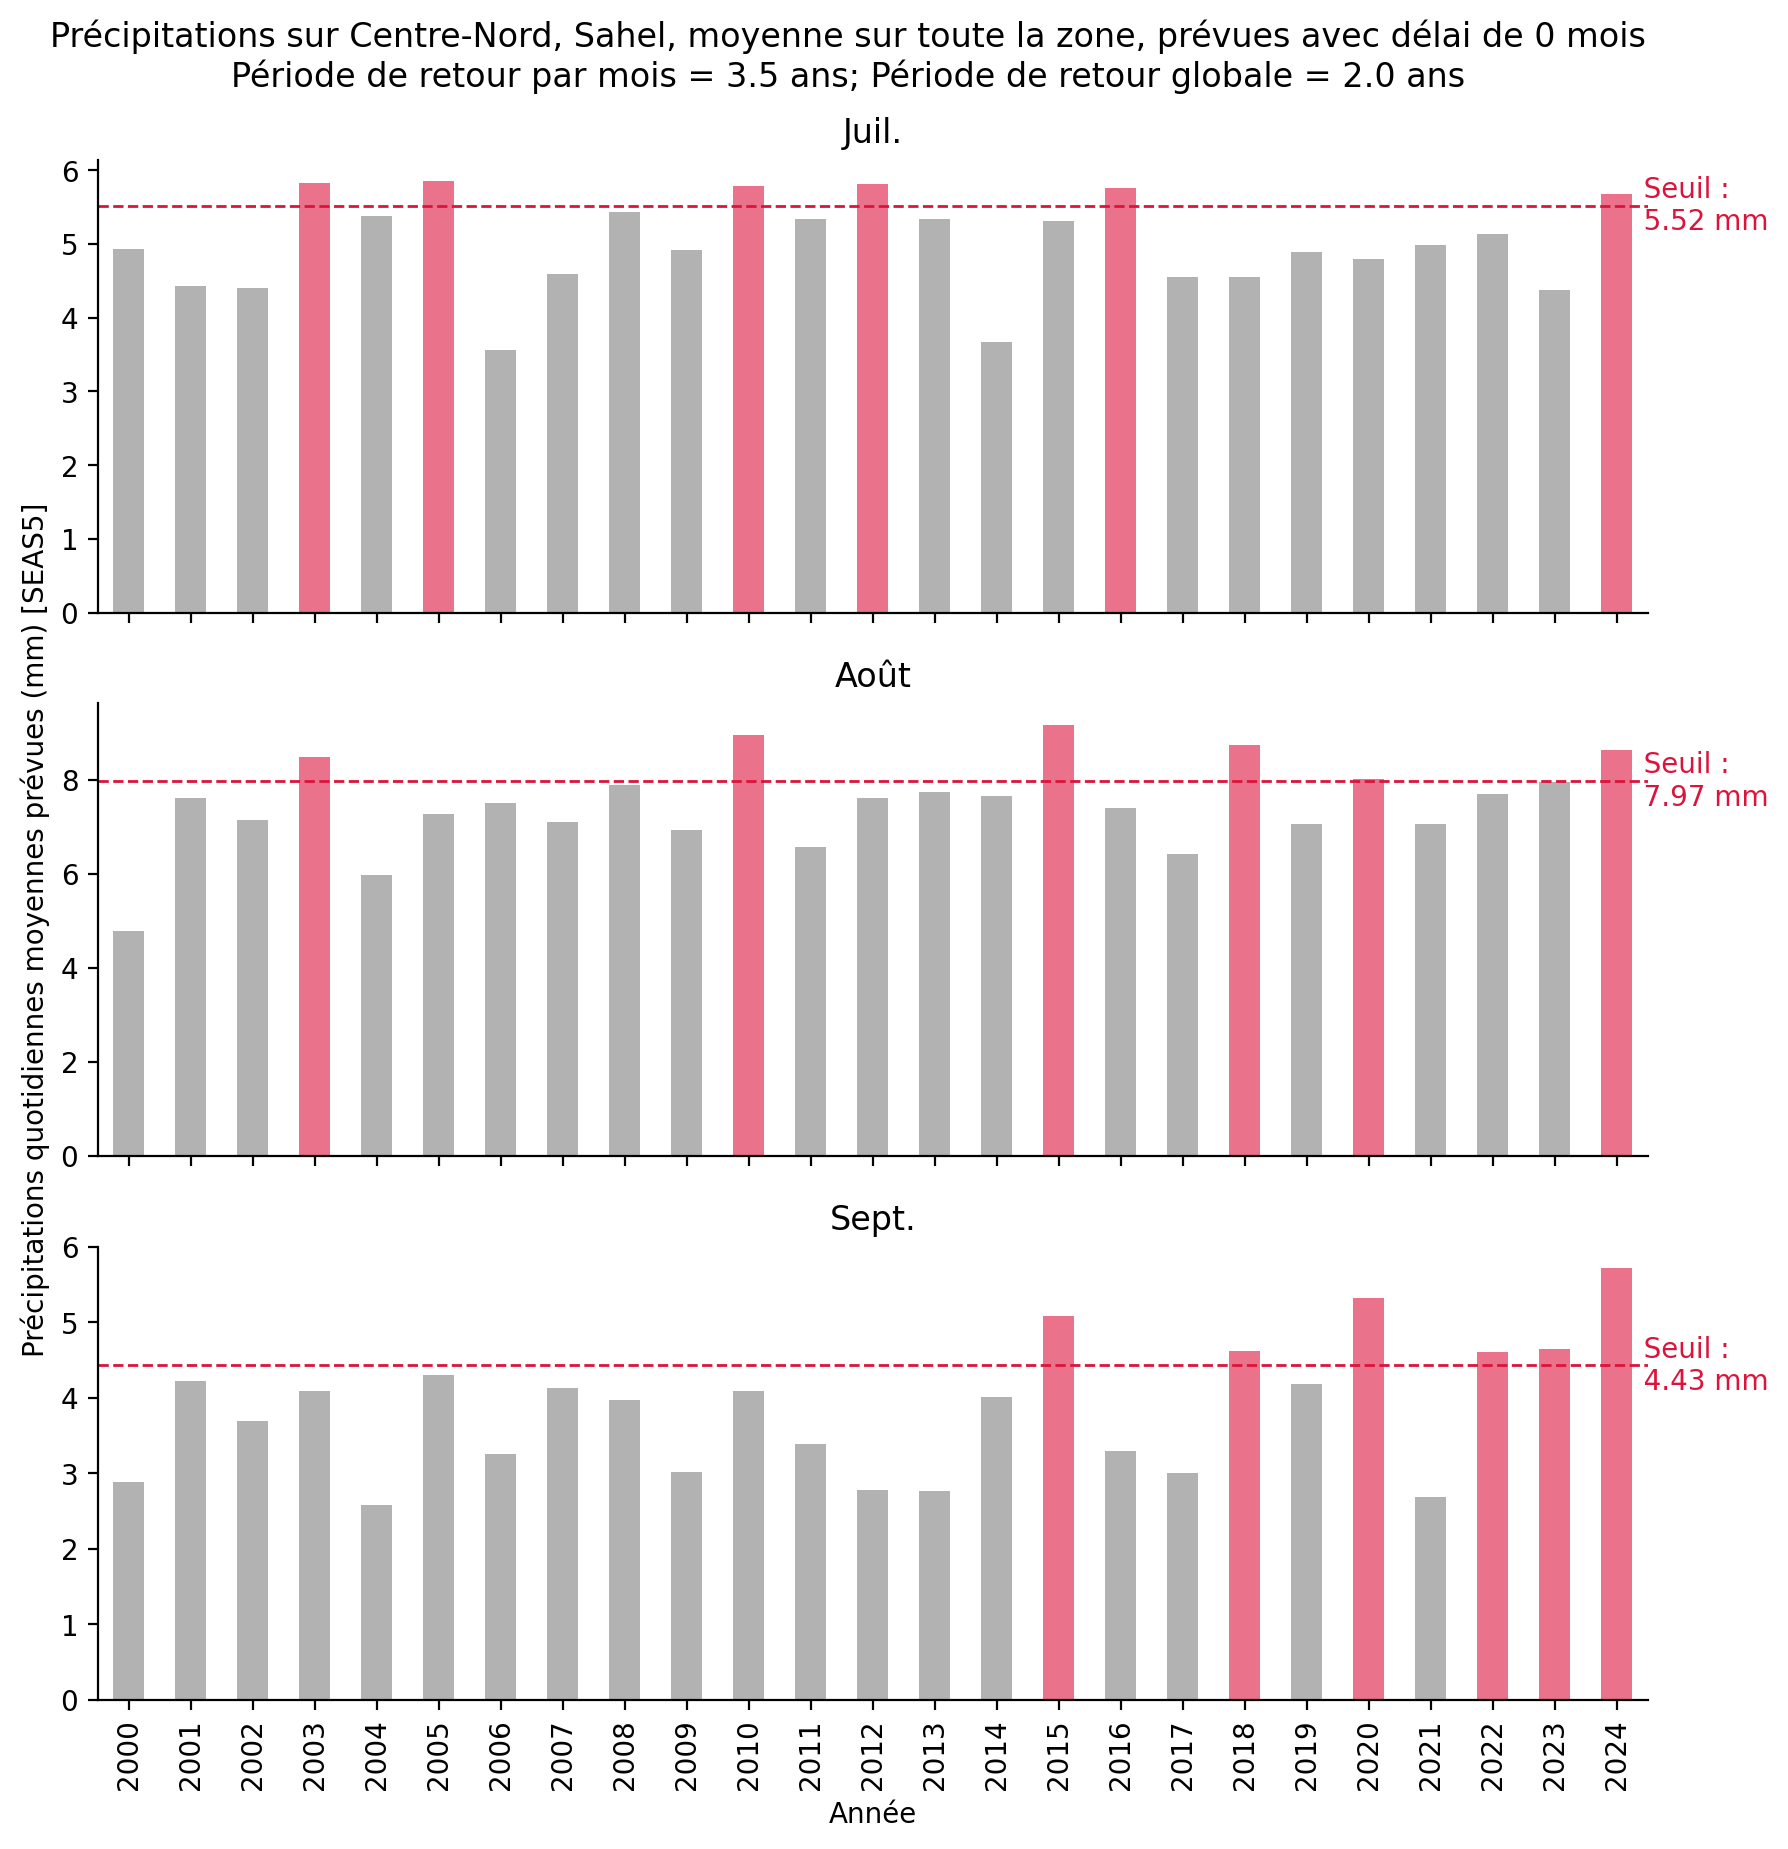

In [125]:
plot_activations(3.5)

,month,thresh
0,7,5.786795
1,8,8.752430
2,9,5.082580


(<Figure size 2000x2000 with 3 Axes>,
 array([<Axes: title={'center': 'Juil.'}, xlabel='year'>,
        <Axes: title={'center': 'Août'}, xlabel='year', ylabel='Précipitations quotidiennes moyennes prévues (mm) [SEAS5]'>,
        <Axes: title={'center': 'Sept.'}, xlabel='Année'>], dtype=object))

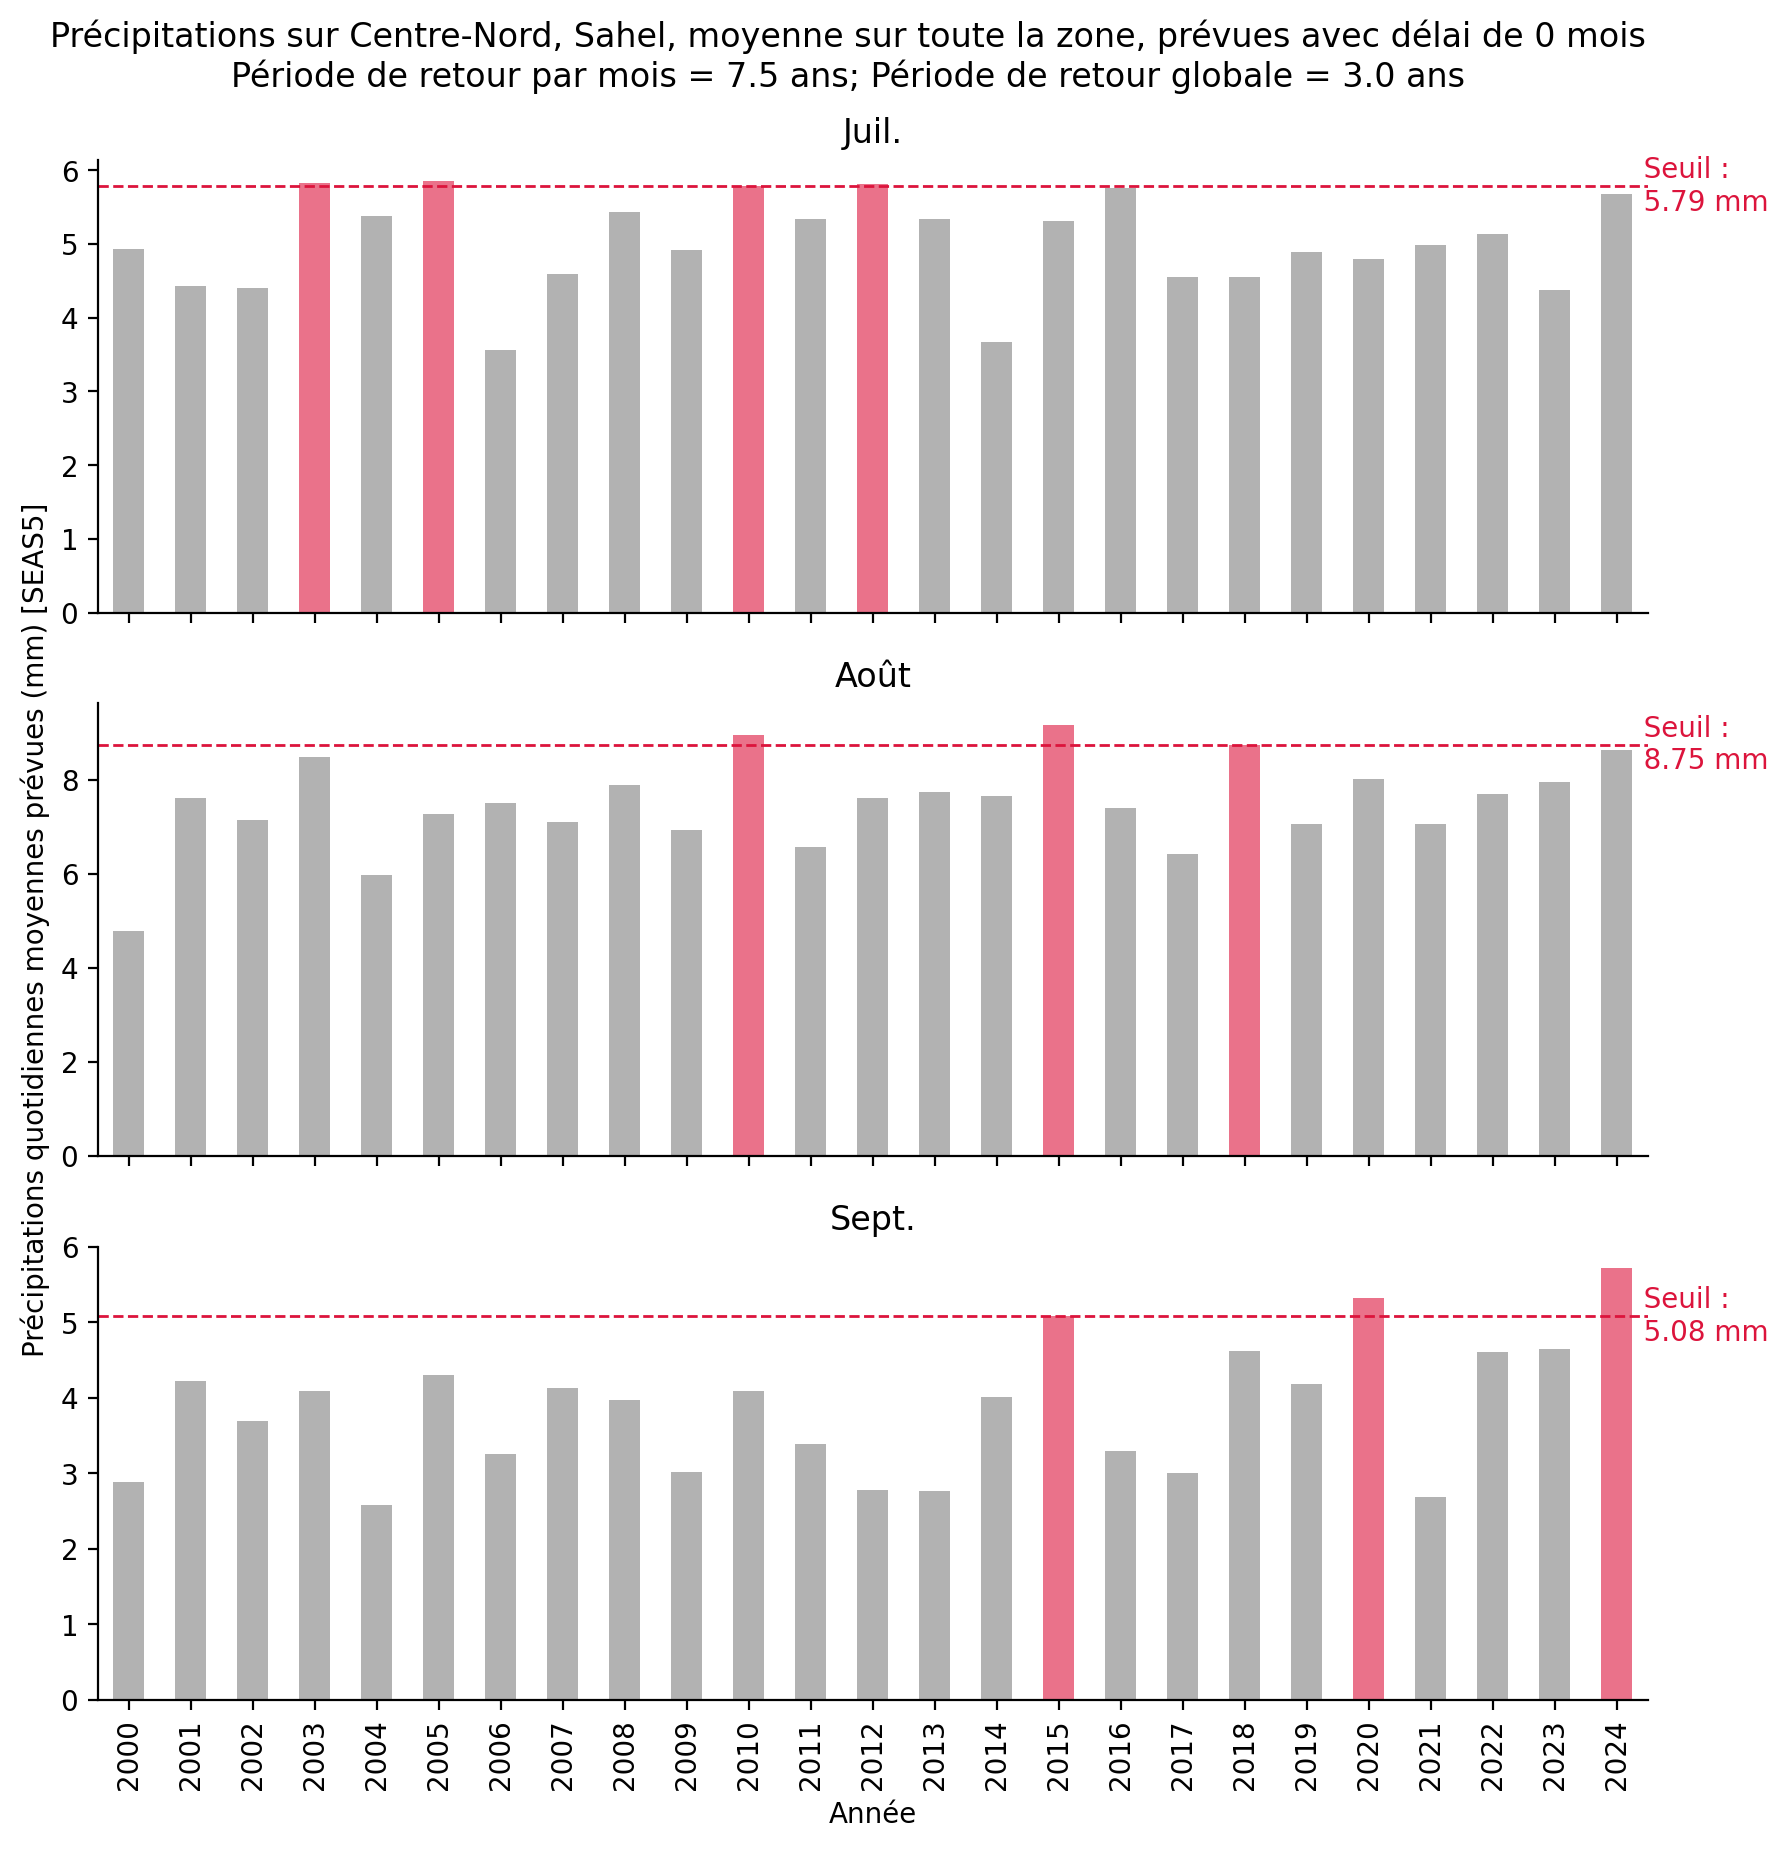

In [126]:
plot_activations(7.5)

,month,thresh
0,7,4.956634
1,8,7.330875
2,9,4.068748


(<Figure size 2000x2000 with 3 Axes>,
 array([<Axes: title={'center': 'Juil.'}, xlabel='year'>,
        <Axes: title={'center': 'Août'}, xlabel='year', ylabel='Précipitations quotidiennes moyennes prévues (mm) [SEAS5]'>,
        <Axes: title={'center': 'Sept.'}, xlabel='Année'>], dtype=object))

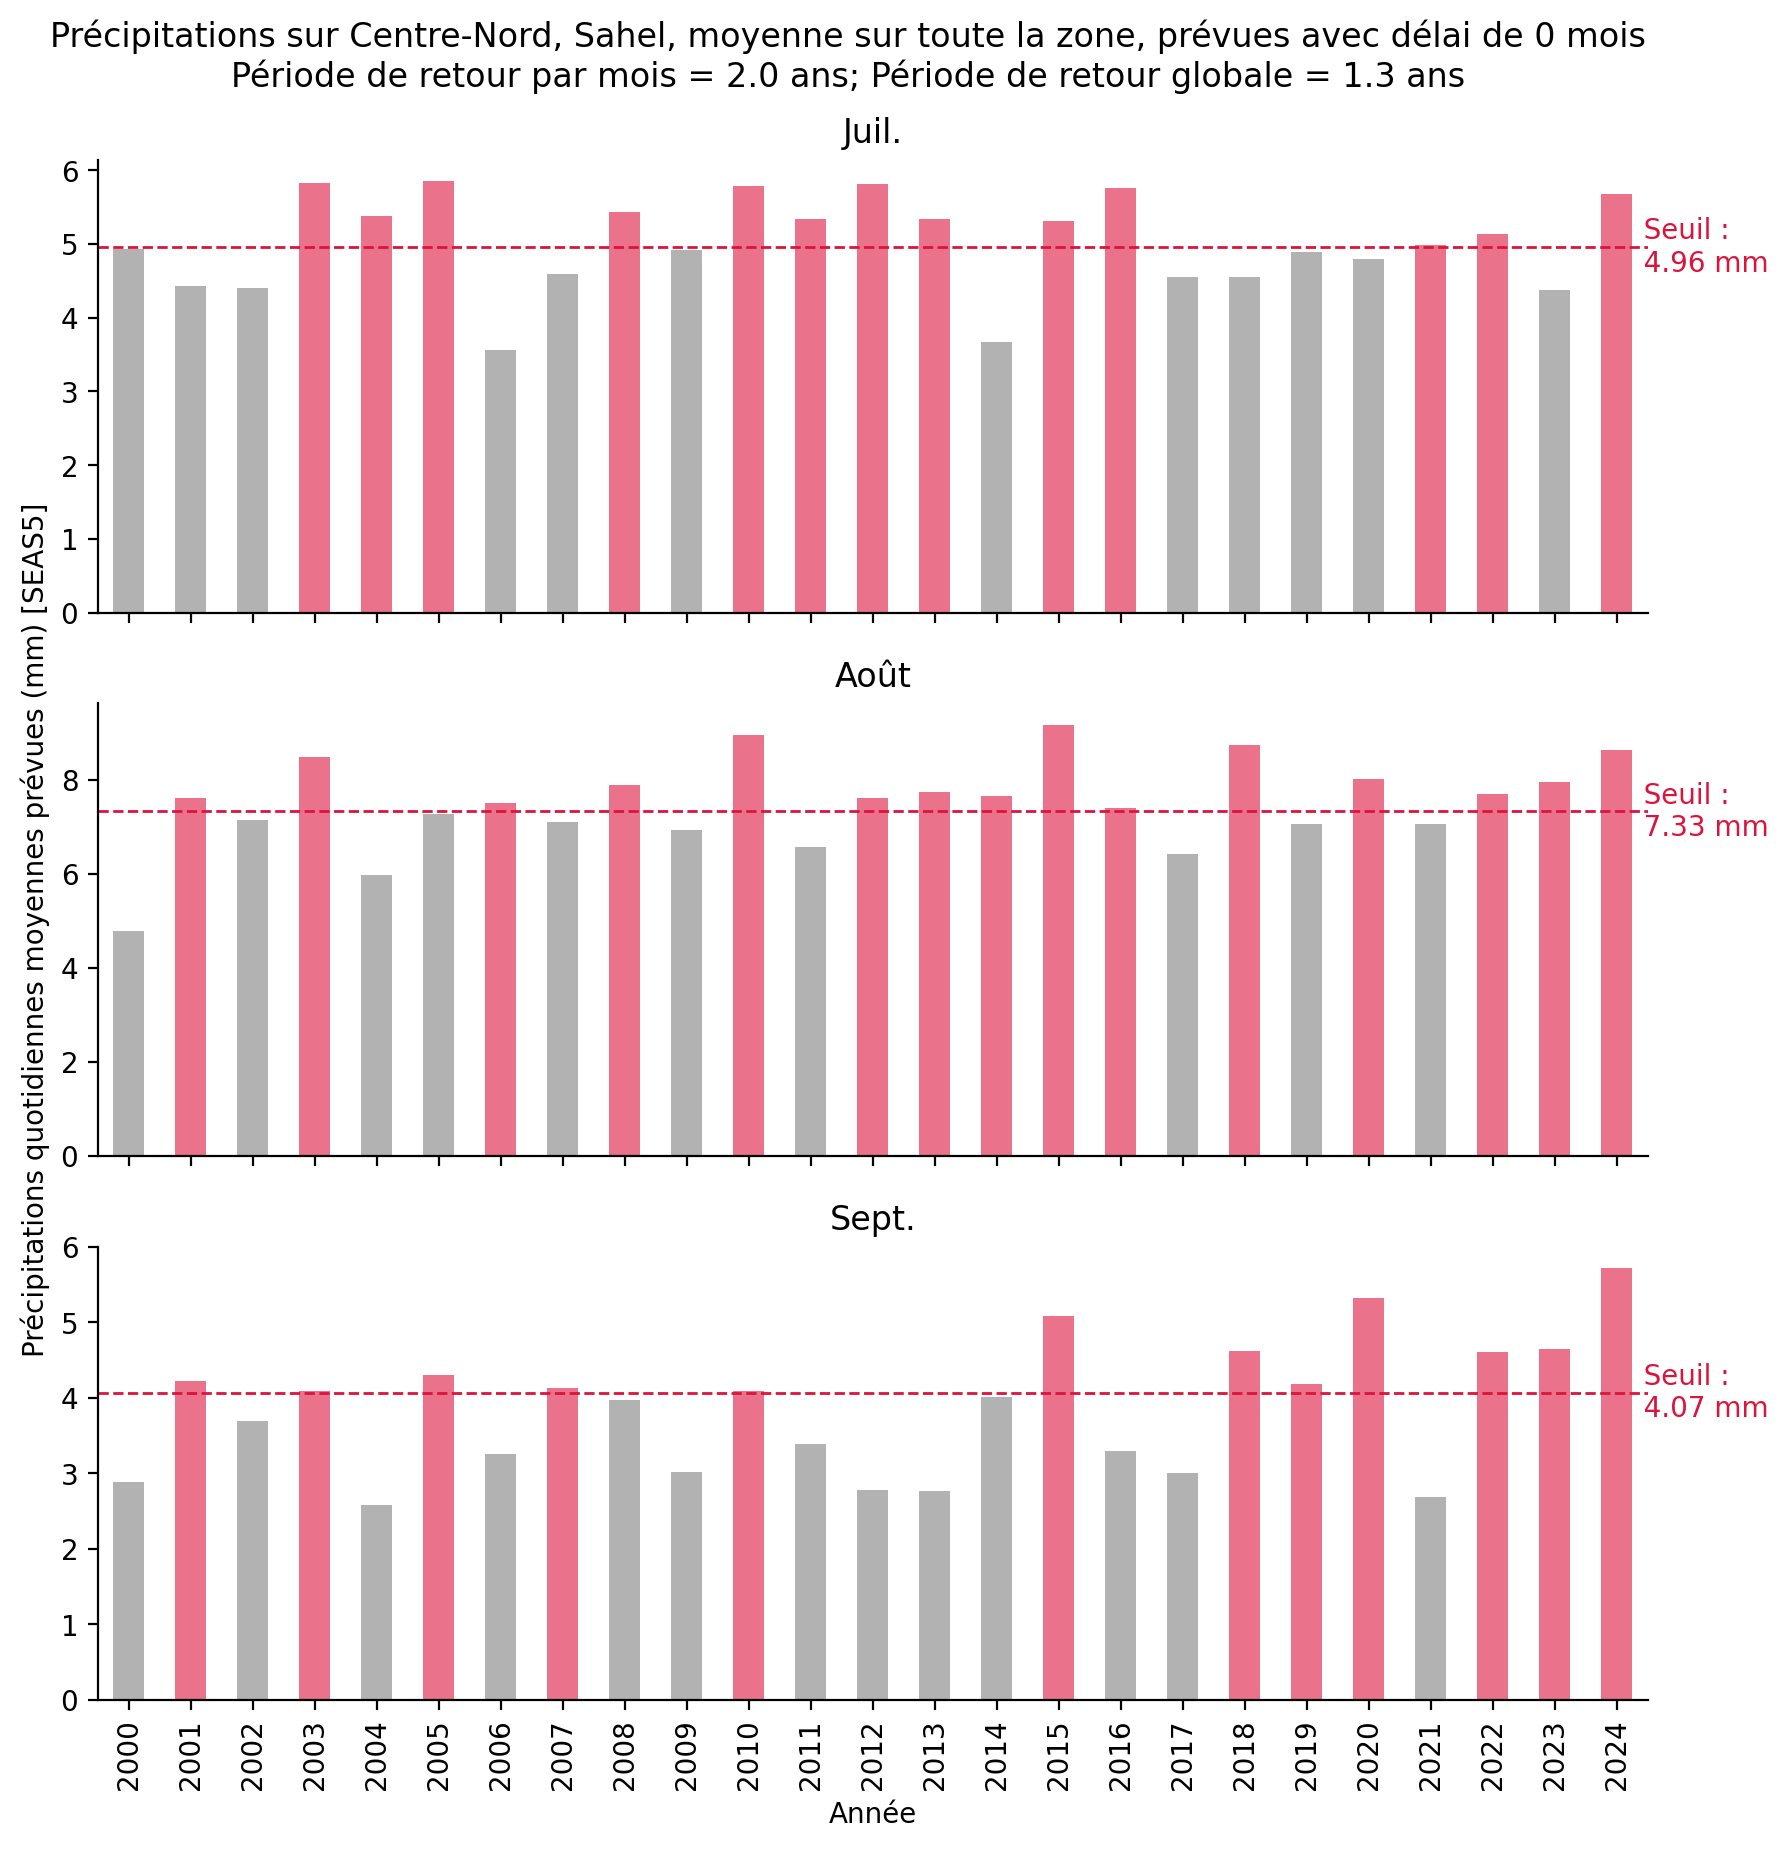

In [133]:
plot_activations(2)

In [44]:
df_seas5_grouped.dtypes

valid_date     datetime64[ns]
issued_date    datetime64[ns]
mean                  float64
dtype: object

In [79]:
df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == "2025-07-01")
    & (df_seas5_grouped["issued_date"] == "2025-07-01")
]

,valid_date,issued_date,mean
3723,2025-07-01,2025-07-01,5.127378
